In [1]:
import warnings
warnings.filterwarnings("ignore")

# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Preprocessing
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
)
from sklearn.pipeline import Pipeline

# Classification
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    RandomForestRegressor, GradientBoostingRegressor
)
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import SVC, SVR
from sklearn.linear_model import LogisticRegression, Ridge, Lasso, LinearRegression

# Metriques
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    mean_squared_error, mean_absolute_error, r2_score
)


# SHAP
try:
    import shap
    SHAP_AVAILABLE = True
    print("SHAP disponible")
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP non installe -- pip install shap")


SHAP disponible



#  MODULE 2 : Modélisation Supervisée

## Partie 1 : Préparation des Données — Split 70 / 15 / 15 (stratifié)

> **Ratio** : 70% Train | 15% Validation | 15% Test  
> **Stratification** sur `Categorie` pour préserver la distribution des classes.  
> Le **set de validation** sert au tuning, le **test** à l'évaluation finale.

In [2]:
import pandas as pd

df_clean = pd.read_csv("../data/df_clean.csv")

In [3]:
feature_cols = ['Poids', 'Volume','Opacite','Conductivite']

In [4]:
df_clean = df_clean.drop_duplicates(subset=feature_cols, keep='first')

In [5]:
feature_cols = [c for c in df_clean.columns if c not in [
    'Categorie',        
    'Rapport_Collecte', 
    'Prix_Revente'
]]
X = df_clean[feature_cols].copy()
y = df_clean['Categorie'].copy()


# 1. SPLIT d'abord (sur données brutes)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"\nSplit terminé:")
print(f"  Train : {X_train.shape}")
print(f"  Val   : {X_val.shape}")
print(f"  Test  : {X_test.shape}")


Split terminé:
  Train : (1578, 6)
  Val   : (338, 6)
  Test  : (339, 6)



## Mise à l'echelle

In [6]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"\n Standardisation terminée (fit sur Train uniquement)")
print(f"  Train mean: {X_train_scaled.mean():.2e}")
print(f"  Test mean:  {X_test_scaled.mean():.2e}")


 Standardisation terminée (fit sur Train uniquement)
  Train mean: -2.35e-17
  Test mean:  8.15e-03



## Partie 2 : Classification — Entrainement et Evaluation

### 2.1 — Random Forest

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
print("\n=== RANDOM FOREST ===")

rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf, average='weighted')
rf_rec = recall_score(y_test, y_pred_rf, average='weighted')
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')

print("Confusion matrix RF:\n", confusion_matrix(y_test, y_pred_rf))
print("Accuracy RF:", rf_acc)
print("Precision RF:", rf_prec)
print("Recall RF:", rf_rec)
print("F1-score RF:", rf_f1)

print("\nClassification Report RF:\n")
print(classification_report(y_test, y_pred_rf))


=== RANDOM FOREST ===
Confusion matrix RF:
 [[ 78   1   0   0]
 [  0  62   2   0]
 [  1   1 102   0]
 [  0   0   0  92]]
Accuracy RF: 0.9852507374631269
Precision RF: 0.9852507374631269
Recall RF: 0.9852507374631269
F1-score RF: 0.9852507374631269

Classification Report RF:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99        79
           1       0.97      0.97      0.97        64
           2       0.98      0.98      0.98       104
           3       1.00      1.00      1.00        92

    accuracy                           0.99       339
   macro avg       0.98      0.98      0.98       339
weighted avg       0.99      0.99      0.99       339



### 2.2 — Gradient Boosting Classifier

In [8]:
gbc = GradientBoostingClassifier(
    n_estimators=50,
    learning_rate=0.05,
    max_depth=2,
    random_state=42
)

gbc.fit(X_train_scaled, y_train)

y_pred_gbc = gbc.predict(X_test_scaled)

gbcl_acc = accuracy_score(y_test, y_pred_gbc)
gbcl_prec = precision_score(y_test, y_pred_gbc, average='weighted')
gbcl_rec = recall_score(y_test, y_pred_gbc, average='weighted')
gbcl_f1 = f1_score(y_test, y_pred_gbc, average='weighted')

print("Confusion Matrix GBC:\n", confusion_matrix(y_test, y_pred_gbc))
print("\nAccuracy GBC:", gbcl_acc)
print("Precision GBC:", gbcl_prec)
print("Recall GBC:", gbcl_rec)
print("F1-score GBC:", gbcl_f1)

print("\nClassification Report GBC:\n")
print(classification_report(y_test, y_pred_gbc))

Confusion Matrix GBC:
 [[78  1  0  0]
 [ 0 64  0  0]
 [ 1  6 97  0]
 [ 0  0  0 92]]

Accuracy GBC: 0.976401179941003
Precision GBC: 0.9784369936432757
Recall GBC: 0.976401179941003
F1-score GBC: 0.9765769644077221

Classification Report GBC:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99        79
           1       0.90      1.00      0.95        64
           2       1.00      0.93      0.97       104
           3       1.00      1.00      1.00        92

    accuracy                           0.98       339
   macro avg       0.97      0.98      0.98       339
weighted avg       0.98      0.98      0.98       339



### 2.3 — k-NN (k optimé sur la validation)

In [9]:
k_range = range(1, 21)
scores = []

for k in k_range:
    knn_tmp = KNeighborsClassifier(n_neighbors=k)
    knn_tmp.fit(X_train_scaled, y_train)
    y_val_pred = knn_tmp.predict(X_val_scaled)
    acc = accuracy_score(y_val, y_val_pred)
    scores.append(acc)

best_k = k_range[scores.index(max(scores))]
print("Meilleur k trouvé =", best_k)

print("\n=== KNN FINAL ===")

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

knn_acc = accuracy_score(y_test, y_pred_knn)
knn_prec = precision_score(y_test, y_pred_knn, average='weighted')
knn_rec = recall_score(y_test, y_pred_knn, average='weighted')
knn_f1 = f1_score(y_test, y_pred_knn, average='weighted')

print("Confusion matrix KNN:\n", confusion_matrix(y_test, y_pred_knn))
print("\nAccuracy KNN:", knn_acc)
print("Precision KNN:", knn_prec)
print("Recall KNN:", knn_rec)
print("F1-score KNN:", knn_f1)

# Classification report
print("\nClassification Report KNN:\n")
print(classification_report(y_test, y_pred_knn))

Meilleur k trouvé = 2

=== KNN FINAL ===
Confusion matrix KNN:
 [[78  1  0  0]
 [ 0 63  1  0]
 [ 1  6 97  0]
 [ 0  0  0 92]]

Accuracy KNN: 0.9734513274336283
Precision KNN: 0.9750406357233158
Recall KNN: 0.9734513274336283
F1-score KNN: 0.9736291817003652

Classification Report KNN:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99        79
           1       0.90      0.98      0.94        64
           2       0.99      0.93      0.96       104
           3       1.00      1.00      1.00        92

    accuracy                           0.97       339
   macro avg       0.97      0.98      0.97       339
weighted avg       0.98      0.97      0.97       339



### 2.4 — Decision Tree (max_depth optimé)

In [10]:
print("\n=== DECISION TREE ===")

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_scaled, y_train)

y_pred_dt = dt.predict(X_test_scaled)

dt_acc = accuracy_score(y_test, y_pred_dt)
dt_prec = precision_score(y_test, y_pred_dt, average='weighted')
dt_rec = recall_score(y_test, y_pred_dt, average='weighted')
dt_f1 = f1_score(y_test, y_pred_dt, average='weighted')

print("Confusion matrix DT:\n", confusion_matrix(y_test, y_pred_dt))
print("Accuracy DT:", dt_acc)
print("Precision DT:", dt_prec)
print("Recall DT:", dt_rec)
print("F1-score DT:", dt_f1)

print("\nClassification Report DT:\n")
print(classification_report(y_test, y_pred_dt))


=== DECISION TREE ===
Confusion matrix DT:
 [[ 78   1   0   0]
 [  0  62   2   0]
 [  1   1 102   0]
 [  0   0   0  92]]
Accuracy DT: 0.9852507374631269
Precision DT: 0.9852507374631269
Recall DT: 0.9852507374631269
F1-score DT: 0.9852507374631269

Classification Report DT:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99        79
           1       0.97      0.97      0.97        64
           2       0.98      0.98      0.98       104
           3       1.00      1.00      1.00        92

    accuracy                           0.99       339
   macro avg       0.98      0.98      0.98       339
weighted avg       0.99      0.99      0.99       339



### 2.5 — SVM Linéaire

In [11]:
print("\n=== SVM LINEAR ===")

svm_l = SVC(kernel='linear')
svm_l.fit(X_train_scaled, y_train)

y_pred_svm_l = svm_l.predict(X_test_scaled)

svm_l_acc = accuracy_score(y_test, y_pred_svm_l)
svm_l_prec = precision_score(y_test, y_pred_svm_l, average='weighted')
svm_l_rec = recall_score(y_test, y_pred_svm_l, average='weighted')
svm_l_f1 = f1_score(y_test, y_pred_svm_l, average='weighted')

print("Confusion matrix SVM Linear:\n", confusion_matrix(y_test, y_pred_svm_l))
print("Accuracy:", svm_l_acc)
print("Precision:", svm_l_prec)
print("Recall:", svm_l_rec)
print("F1-score:", svm_l_f1)

print("\nClassification Report SVM Linear:\n")
print(classification_report(y_test, y_pred_svm_l))


=== SVM LINEAR ===
Confusion matrix SVM Linear:
 [[78  1  0  0]
 [ 0 63  1  0]
 [ 1  6 97  0]
 [ 0  0  0 92]]
Accuracy: 0.9734513274336283
Precision: 0.9750406357233158
Recall: 0.9734513274336283
F1-score: 0.9736291817003652

Classification Report SVM Linear:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99        79
           1       0.90      0.98      0.94        64
           2       0.99      0.93      0.96       104
           3       1.00      1.00      1.00        92

    accuracy                           0.97       339
   macro avg       0.97      0.98      0.97       339
weighted avg       0.98      0.97      0.97       339



### 2.6 — SVM RBF

In [12]:
print("\n=== SVM RBF ===")

svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train_scaled, y_train)

y_pred_svm_rbf = svm_rbf.predict(X_test_scaled)

svm_rbf_acc = accuracy_score(y_test, y_pred_svm_rbf)
svm_rbf_prec = precision_score(y_test, y_pred_svm_rbf, average='weighted')
svm_rbf_rec = recall_score(y_test, y_pred_svm_rbf, average='weighted')
svm_rbf_f1 = f1_score(y_test, y_pred_svm_rbf, average='weighted')

print("Confusion matrix SVM RBF:\n", confusion_matrix(y_test, y_pred_svm_rbf))
print("Accuracy:", svm_rbf_acc)
print("Precision:", svm_rbf_prec)
print("Recall:", svm_rbf_rec)
print("F1-score:", svm_rbf_f1)

print("\nClassification Report SVM RBF:\n")
print(classification_report(y_test, y_pred_svm_rbf))


=== SVM RBF ===
Confusion matrix SVM RBF:
 [[78  1  0  0]
 [ 0 63  1  0]
 [ 1  6 96  1]
 [ 0  0  0 92]]
Accuracy: 0.9705014749262537
Precision: 0.9720902293207033
Recall: 0.9705014749262537
F1-score: 0.9705754889746436

Classification Report SVM RBF:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99        79
           1       0.90      0.98      0.94        64
           2       0.99      0.92      0.96       104
           3       0.99      1.00      0.99        92

    accuracy                           0.97       339
   macro avg       0.97      0.97      0.97       339
weighted avg       0.97      0.97      0.97       339



### 2.7 — Régression Logistique

In [13]:
print("\n=== LOGISTIC REGRESSION ===")

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

lr_acc = accuracy_score(y_test, y_pred_lr)
lr_prec = precision_score(y_test, y_pred_lr, average='weighted')
lr_rec = recall_score(y_test, y_pred_lr, average='weighted')
lr_f1 = f1_score(y_test, y_pred_lr, average='weighted')

print("Confusion matrix LR:\n", confusion_matrix(y_test, y_pred_lr))
print("Accuracy:", lr_acc)
print("Precision:", lr_prec)
print("Recall:", lr_rec)
print("F1-score:", lr_f1)

print("\nClassification Report LR:\n")
print(classification_report(y_test, y_pred_lr))


=== LOGISTIC REGRESSION ===
Confusion matrix LR:
 [[78  1  0  0]
 [ 0 63  1  0]
 [ 1  6 97  0]
 [ 0  0  0 92]]
Accuracy: 0.9734513274336283
Precision: 0.9750406357233158
Recall: 0.9734513274336283
F1-score: 0.9736291817003652

Classification Report LR:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99        79
           1       0.90      0.98      0.94        64
           2       0.99      0.93      0.96       104
           3       1.00      1.00      1.00        92

    accuracy                           0.97       339
   macro avg       0.97      0.98      0.97       339
weighted avg       0.98      0.97      0.97       339



### 2. — Tableau comparatif des modèles de classification

In [14]:
results_clf = pd.DataFrame({
    'Accuracy': [rf_acc, gbcl_acc, knn_acc, dt_acc, svm_l_acc, svm_rbf_acc, lr_acc],
    'Precision': [rf_prec, gbcl_prec, knn_prec, dt_prec, svm_l_prec, svm_rbf_prec, lr_prec],
    'Recall': [rf_rec, gbcl_rec, knn_rec, dt_rec, svm_l_rec, svm_rbf_rec, lr_rec],
    'F1-score': [rf_f1, gbcl_f1, knn_f1, dt_f1, svm_l_f1, svm_rbf_f1, lr_f1],
}, index=[
    'Random Forest',
    'Gradient Boosting',
    f'kNN (k={best_k})',
    f'Decision Tree (d=5)',
    'SVM Linear',
    'SVM RBF',
    'Logistic Regression'
]).round(4).sort_values('F1-score', ascending=False)

print("\n=== TABLEAU COMPARATIF ===")
display(results_clf)


=== TABLEAU COMPARATIF ===


,Accuracy,Precision,Recall,F1-score
Random Forest,0.9853,0.9853,0.9853,0.9853
Decision Tree (d=5),0.9853,0.9853,0.9853,0.9853
Gradient Boosting,0.9764,0.9784,0.9764,0.9766
kNN (k=2),0.9735,0.9750,0.9735,0.9736
SVM Linear,0.9735,0.9750,0.9735,0.9736
Logistic Regression,0.9735,0.9750,0.9735,0.9736
SVM RBF,0.9705,0.9721,0.9705,0.9706



## Partie 3 : Sélection de Features avec SHAP Values

> **SHAP** (SHapley Additive exPlanations) mesure la contribution de chaque feature à chaque prédiction.  


=== SHAP Feature Importance ===


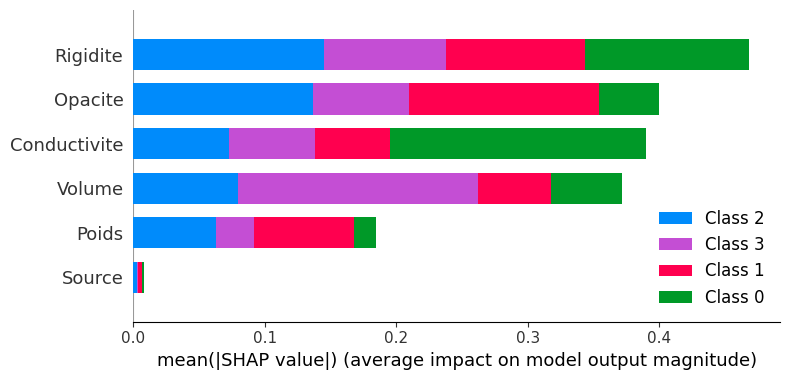


Feature importance SHAP :
Rigidite        0.117051
Opacite         0.099948
Conductivite    0.097442
Volume          0.092866
Poids           0.046159
Source          0.002141
dtype: float64

Features sélectionnées :
['Rigidite', 'Opacite', 'Conductivite', 'Volume']


In [15]:


print("=== SHAP Feature Importance ===")

# explainer
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_scaled)

# gestion multi-classe
sv = shap_values[0] if isinstance(shap_values, list) else shap_values

# 1. GRAPH SHAP (bar)
shap.summary_plot(
    sv,
    X_test_scaled,
    feature_names=X.columns,
    plot_type="bar",
    show=True
)

# 2. IMPORTANCE SHAP
if sv.ndim == 3:
    importance = np.abs(sv).mean(axis=(0, 2))
else:
    importance = np.abs(sv).mean(axis=0)

shap_importance = pd.Series(
    importance,
    index=X.columns
).sort_values(ascending=False)

print("\nFeature importance SHAP :")
print(shap_importance)

# 3. SELECTION FEATURES
threshold = shap_importance.quantile(0.25)
selected_features = shap_importance[shap_importance > threshold].index.tolist()

print("\nFeatures sélectionnées :")
print(selected_features)


##  Tuning des Hyperparamètres

### 5.1 — GridSearchCV 

In [16]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

print("\n=== GRIDSEARCH Random Forest ===")

# paramètres (réduits pour éviter lenteur)
parameters = {
    'n_estimators': [100, 150],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

# modèle
model = RandomForestClassifier(random_state=42, class_weight='balanced')

# GridSearch (style prof)
clf = GridSearchCV(
    model,
    parameters,
    scoring='f1_weighted',
    cv=5
)

grille = clf.fit(X_train_scaled, y_train)

# meilleurs paramètres
print("Best params:", grille.best_params_)
print("Best CV score:", grille.best_score_)

# prédiction
y_pred_rf_grid = grille.predict(X_test_scaled)

# métriques
rf_grid_acc = accuracy_score(y_test, y_pred_rf_grid)
rf_grid_prec = precision_score(y_test, y_pred_rf_grid, average='weighted')
rf_grid_rec = recall_score(y_test, y_pred_rf_grid, average='weighted')
rf_grid_f1 = f1_score(y_test, y_pred_rf_grid, average='weighted')

print('Confusion matrix RF \n', confusion_matrix(y_test, y_pred_rf_grid))
print('Accuracy RF', rf_grid_acc)
print('Precision RF', rf_grid_prec)
print('Recall RF', rf_grid_rec)
print('F1-score RF', rf_grid_f1)


=== GRIDSEARCH Random Forest ===
Best params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Best CV score: 0.991140077742541
Confusion matrix RF 
 [[ 78   1   0   0]
 [  0  62   2   0]
 [  1   1 102   0]
 [  0   0   0  92]]
Accuracy RF 0.9852507374631269
Precision RF 0.9852507374631269
Recall RF 0.9852507374631269
F1-score RF 0.9852507374631269


### 5.2 — Optuna (Bayesian Optimization / TPE)

> **Optuna** utilise le TPE (Tree-structured Parzen Estimator) pour explorer intelligemment  
> l'espace des hyperparamètres, bien plus efficace que la grille exhaustive pour les grands espaces.

In [17]:
import optuna
from sklearn.model_selection import cross_val_score

print("\n=== Optuna - Random Forest ===")

def objective(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
    }

    model = RandomForestClassifier(
        **params,
        random_state=42,
        class_weight='balanced'
    )

    score = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,  # plus rapide
        scoring='f1_weighted'
    ).mean()

    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)  # rapide

best_params = study.best_params

best_rf_opt = RandomForestClassifier(
    **best_params,
    random_state=42,
    class_weight='balanced'
)

best_rf_opt.fit(X_train_scaled, y_train)

y_pred_opt = best_rf_opt.predict(X_test_scaled)

# métriques
opt_acc = accuracy_score(y_test, y_pred_opt)
opt_prec = precision_score(y_test, y_pred_opt, average='weighted')
opt_rec = recall_score(y_test, y_pred_opt, average='weighted')
opt_f1 = f1_score(y_test, y_pred_opt, average='weighted')

print("\nBest Optuna params:", best_params)
print("Best CV F1:", study.best_value)
print("Test F1:", opt_f1)
print("Test Acc:", opt_acc)

[I 2026-05-04 19:06:21,333] A new study created in memory with name: no-name-efcc6806-6524-4b29-a1d7-26a03de1e247



=== Optuna - Random Forest ===


[I 2026-05-04 19:06:22,620] Trial 0 finished with value: 0.9898918042604474 and parameters: {'n_estimators': 130, 'max_depth': 14, 'min_samples_split': 6}. Best is trial 0 with value: 0.9898918042604474.
[I 2026-05-04 19:06:23,527] Trial 1 finished with value: 0.9867197716976097 and parameters: {'n_estimators': 92, 'max_depth': 5, 'min_samples_split': 8}. Best is trial 0 with value: 0.9898918042604474.
[I 2026-05-04 19:06:25,077] Trial 2 finished with value: 0.9886301969590804 and parameters: {'n_estimators': 155, 'max_depth': 13, 'min_samples_split': 8}. Best is trial 0 with value: 0.9898918042604474.
[I 2026-05-04 19:06:26,380] Trial 3 finished with value: 0.9867359068333293 and parameters: {'n_estimators': 117, 'max_depth': 5, 'min_samples_split': 7}. Best is trial 0 with value: 0.9898918042604474.
[I 2026-05-04 19:06:27,774] Trial 4 finished with value: 0.9867197716976097 and parameters: {'n_estimators': 138, 'max_depth': 5, 'min_samples_split': 8}. Best is trial 0 with value: 0.98


Best Optuna params: {'n_estimators': 200, 'max_depth': 10, 'min_samples_split': 3}
Best CV F1: 0.9917866890531155
Test F1: 0.9852507374631269
Test Acc: 0.9852507374631269


### 5.3 — Comparaison : Baseline vs GridSearch vs Optuna

In [18]:
print("\n=== COMPARAISON FINALE TUNING ===")

comparison = pd.DataFrame({
    'Modèle': [
        'Random Forest (Baseline)',
        'Random Forest (GridSearch)',
        'Random Forest (Optuna)'
    ],
    'F1-score': [
        rf_f1,        # baseline
        rf_grid_f1,   # grid
        opt_f1        # optuna
    ],
    'Accuracy': [
        rf_acc,
        rf_grid_acc,
        opt_acc
    ]
}).sort_values('F1-score', ascending=False)

display(comparison)


=== COMPARAISON FINALE TUNING ===


,Modèle,F1-score,Accuracy
0,Random Forest (Baseline),0.985251,0.985251
1,Random Forest (GridSearch),0.985251,0.985251
2,Random Forest (Optuna),0.985251,0.985251


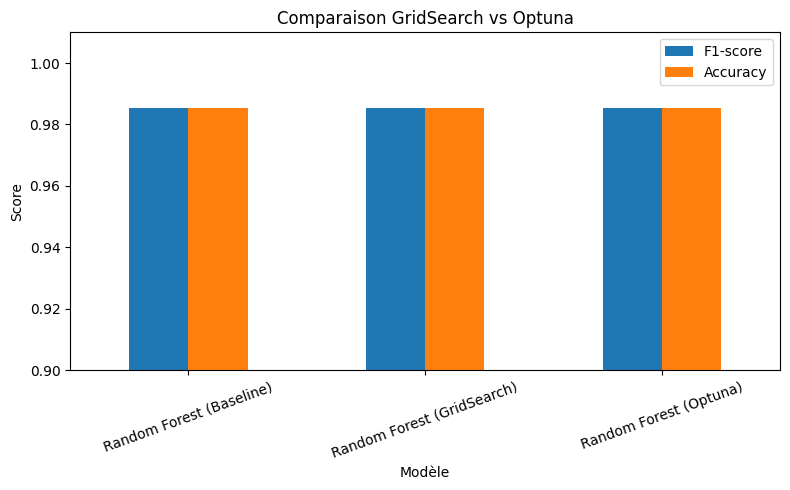

In [19]:
comparison.set_index('Modèle').plot(kind='bar', figsize=(8,5))
plt.title("Comparaison GridSearch vs Optuna")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.ylim(0.9, 1.01)
plt.tight_layout()
plt.show()